# 08. 객체검출 성능평가 mAP 실습

## 학습 목표
1. IoU(Intersection over Union) 계산 원리를 이해한다.
2. Precision-Recall 곡선을 직접 구성한다.
3. AP@0.5와 mAP@0.5를 구현해 성능을 평가한다.

---

이 노트북은 **모델 추론 결과가 있다고 가정**하고,
GT(정답 bbox)와 Pred(예측 bbox + confidence)를 비교해 지표를 계산하는 실습입니다.

In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "detection_eval"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "mouse_bite",
    1: "spur",
    2: "missing_hole",
    3: "short",
    4: "open_circuit",
    5: "spurious_copper",
}

print("DATA_ROOT:", DATA_ROOT)
print("OUT_DIR:", OUT_DIR)

DATA_ROOT: C:\MyCursorLab\10_프로젝트\data\pcb-defect-dataset\pcb-defect-dataset
OUT_DIR: C:\MyCursorLab\10_프로젝트\outputs\detection_eval


## 1) 준비: YOLO 라벨 로드 및 bbox 변환

YOLO 형식: `class cx cy w h` (정규화 좌표)

IoU 계산을 위해 `(x1, y1, x2, y2)` 형식으로 변환합니다.

In [2]:
def yolo_to_xyxy(cx, cy, w, h):
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return x1, y1, x2, y2


def load_gt(split="test", max_images=200):
    gt = defaultdict(list)  # image_id -> list of dict(class_id, bbox, used)
    img_dir = DATA_ROOT / split / "images"
    lbl_dir = DATA_ROOT / split / "labels"

    img_paths = sorted(img_dir.glob("*.jpg"))[:max_images]
    for img_path in img_paths:
        lbl_path = lbl_dir / f"{img_path.stem}.txt"
        if not lbl_path.exists():
            continue

        txt = lbl_path.read_text(encoding="utf-8").strip()
        if not txt:
            continue

        for line in txt.splitlines():
            p = line.split()
            if len(p) != 5:
                continue
            cls, cx, cy, w, h = map(float, p)
            cls = int(cls)
            if cls not in CLASS_NAMES:
                continue
            bbox = yolo_to_xyxy(cx, cy, w, h)
            gt[img_path.stem].append({
                "class_id": cls,
                "bbox": bbox,
                "used": False,
            })
    return gt

gt = load_gt(split="test", max_images=200)
print("GT 이미지 수:", len(gt))
print("GT bbox 총개수:", sum(len(v) for v in gt.values()))

GT 이미지 수: 200
GT bbox 총개수: 380


In [3]:
def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_w = max(0.0, inter_x2 - inter_x1)
    inter_h = max(0.0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0.0, ax2 - ax1) * max(0.0, ay2 - ay1)
    area_b = max(0.0, bx2 - bx1) * max(0.0, by2 - by1)

    union = area_a + area_b - inter + 1e-12
    return inter / union

# IoU sanity check
box1 = (0.1, 0.1, 0.4, 0.4)
box2 = (0.2, 0.2, 0.5, 0.5)
print("IoU(box1, box2)=", round(iou_xyxy(box1, box2), 4))

IoU(box1, box2)= 0.2857


## 2) 예측 결과(prediction) 준비

실습 편의를 위해 GT 기반으로 예측을 시뮬레이션합니다.
- 일부는 GT 근처에 높은 confidence로 생성(정탐 후보)
- 일부는 랜덤 박스로 생성(오탐 후보)

실제 프로젝트에서는 모델 추론 결과를 그대로 넣으면 됩니다.

In [4]:
rng = np.random.default_rng(42)


def clamp01(x):
    return max(0.0, min(1.0, x))


def jitter_box(box, scale=0.03):
    x1, y1, x2, y2 = box
    dx1, dy1, dx2, dy2 = rng.normal(0, scale, 4)
    nx1 = clamp01(x1 + dx1)
    ny1 = clamp01(y1 + dy1)
    nx2 = clamp01(x2 + dx2)
    ny2 = clamp01(y2 + dy2)
    # 좌표 역전 방지
    if nx2 <= nx1:
        nx2 = clamp01(nx1 + 0.01)
    if ny2 <= ny1:
        ny2 = clamp01(ny1 + 0.01)
    return (nx1, ny1, nx2, ny2)


def random_box():
    x1, y1 = rng.uniform(0, 0.8, 2)
    w, h = rng.uniform(0.05, 0.25, 2)
    return (x1, y1, clamp01(x1 + w), clamp01(y1 + h))


def simulate_predictions(gt_dict):
    preds = []
    for image_id, objs in gt_dict.items():
        # GT 기반 positive-like 예측
        for o in objs:
            if rng.random() < 0.85:  # 일부 miss 유도
                preds.append({
                    "image_id": image_id,
                    "class_id": o["class_id"],
                    "conf": float(rng.uniform(0.55, 0.98)),
                    "bbox": jitter_box(o["bbox"], scale=0.025),
                })

        # 랜덤 false prediction
        n_fp = rng.integers(0, 3)
        for _ in range(n_fp):
            preds.append({
                "image_id": image_id,
                "class_id": int(rng.integers(0, 6)),
                "conf": float(rng.uniform(0.20, 0.85)),
                "bbox": random_box(),
            })

    return preds

preds = simulate_predictions(gt)
print("생성된 예측 수:", len(preds))
pd.DataFrame(preds).head()

생성된 예측 수: 522


,image_id,class_id,conf,bbox
0,l_light_01_missing_hole_04_2_600,2,0.738718,"(0.37541127989516143, 0.15186411790978033, 0.3..."
1,l_light_01_missing_hole_04_2_600,2,0.888008,"(0.22957997106239278, 0.3737239018106605, 0.31..."
2,l_light_01_missing_hole_04_2_600,3,0.734795,"(0.3547313590618649, 0.18179097742782152, 0.51..."
3,l_light_01_missing_hole_04_2_600,5,0.610582,"(0.6064701920682991, 0.2836207745038947, 0.850..."
4,l_light_01_missing_hole_07_2_600,2,0.633695,"(0.7466577296388338, 0.03578610160910196, 0.80..."


## 3) Precision-Recall 및 AP@0.5 계산

평가 규칙 (VOC 스타일 단순화):
1. class별로 prediction을 confidence 내림차순 정렬
2. 각 prediction에 대해 같은 이미지의 GT 중 IoU 최대를 찾음
3. `IoU >= 0.5`이고 아직 매칭되지 않은 GT면 TP, 아니면 FP
4. 누적 TP/FP로 Precision, Recall 계산
5. PR 곡선 면적(적분)으로 AP 계산

In [5]:
def prepare_gt_by_class(gt_dict):
    gt_by_class = defaultdict(lambda: defaultdict(list))
    for image_id, objs in gt_dict.items():
        for o in objs:
            gt_by_class[o["class_id"]][image_id].append({
                "bbox": o["bbox"],
                "used": False,
            })
    return gt_by_class


def compute_ap_for_class(preds, gt_dict, class_id, iou_thr=0.5):
    # class별 GT 준비
    gt_by_class = prepare_gt_by_class(gt_dict)
    gt_cls = gt_by_class[class_id]
    n_gt = sum(len(v) for v in gt_cls.values())

    # class별 prediction 정렬
    pred_cls = [p for p in preds if p["class_id"] == class_id]
    pred_cls = sorted(pred_cls, key=lambda x: x["conf"], reverse=True)

    if n_gt == 0:
        return {
            "class_id": class_id,
            "n_gt": 0,
            "n_pred": len(pred_cls),
            "precision": np.array([]),
            "recall": np.array([]),
            "ap": np.nan,
        }

    tp = np.zeros(len(pred_cls), dtype=np.float32)
    fp = np.zeros(len(pred_cls), dtype=np.float32)

    for i, p in enumerate(pred_cls):
        image_id = p["image_id"]
        pred_box = p["bbox"]

        gts = gt_cls.get(image_id, [])
        best_iou = 0.0
        best_j = -1

        for j, g in enumerate(gts):
            iou = iou_xyxy(pred_box, g["bbox"])
            if iou > best_iou:
                best_iou = iou
                best_j = j

        if best_iou >= iou_thr and best_j >= 0 and not gts[best_j]["used"]:
            tp[i] = 1.0
            gts[best_j]["used"] = True
        else:
            fp[i] = 1.0

    ctp = np.cumsum(tp)
    cfp = np.cumsum(fp)

    recall = ctp / (n_gt + 1e-12)
    precision = ctp / (ctp + cfp + 1e-12)

    # AP 계산: precision envelope + recall 적분
    mrec = np.concatenate(([0.0], recall, [1.0]))
    mpre = np.concatenate(([0.0], precision, [0.0]))

    for k in range(len(mpre) - 1, 0, -1):
        mpre[k - 1] = max(mpre[k - 1], mpre[k])

    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx + 1] - mrec[idx]) * mpre[idx + 1])

    return {
        "class_id": class_id,
        "n_gt": n_gt,
        "n_pred": len(pred_cls),
        "precision": precision,
        "recall": recall,
        "ap": float(ap),
    }

results = []
for cid in sorted(CLASS_NAMES):
    results.append(compute_ap_for_class(preds, gt, cid, iou_thr=0.5))

ap_table = pd.DataFrame([
    {
        "class_id": r["class_id"],
        "class_name": CLASS_NAMES[r["class_id"]],
        "n_gt": r["n_gt"],
        "n_pred": r["n_pred"],
        "AP@0.5": r["ap"],
    }
    for r in results
])

map50 = ap_table["AP@0.5"].mean()
print(f"mAP@0.5 = {map50:.4f}")
display(ap_table)

mAP@0.5 = 0.0069


,class_id,class_name,n_gt,n_pred,AP@0.5
0,0,mouse_bite,54,82,0.000741
1,1,spur,62,94,0.002688
2,2,missing_hole,63,78,0.009789
3,3,short,86,107,0.016811
4,4,open_circuit,42,75,0.000000
5,5,spurious_copper,73,86,0.011447


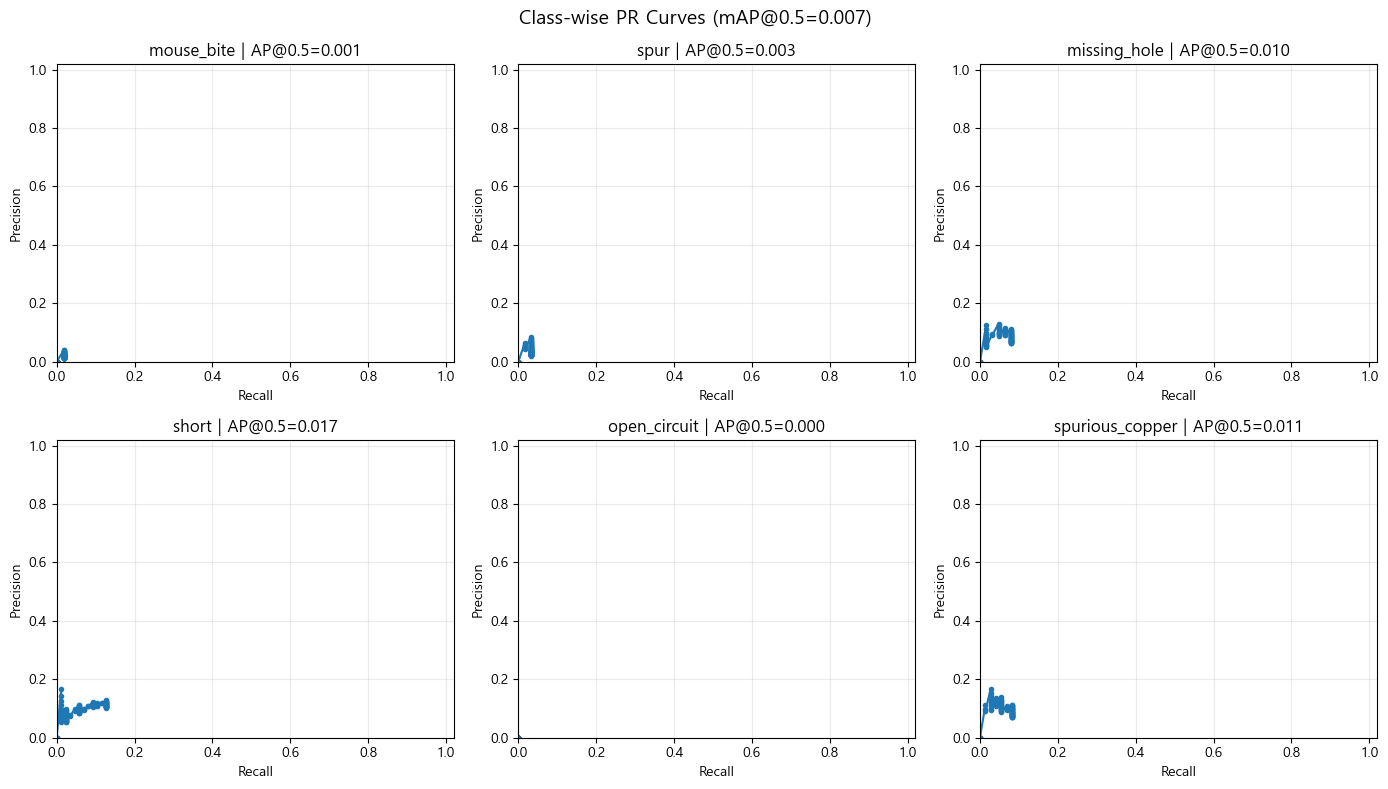

In [6]:
# PR 곡선 시각화
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, r in enumerate(results):
    ax = axes[i]
    cid = r["class_id"]
    if len(r["recall"]) == 0:
        ax.text(0.5, 0.5, "GT 없음", ha="center", va="center")
        ax.set_title(f"{CLASS_NAMES[cid]}")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        continue

    ax.plot(r["recall"], r["precision"], marker=".")
    ax.set_title(f"{CLASS_NAMES[cid]} | AP@0.5={r['ap']:.3f}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)

plt.suptitle(f"Class-wise PR Curves (mAP@0.5={map50:.3f})", fontsize=14)
plt.tight_layout()
plt.show()

In [7]:
# 결과 저장
ap_table.to_csv(OUT_DIR / "ap_table_map50.csv", index=False, encoding="utf-8-sig")

pr_rows = []
for r in results:
    cid = r["class_id"]
    for p, q in zip(r["precision"], r["recall"]):
        pr_rows.append({
            "class_id": cid,
            "class_name": CLASS_NAMES[cid],
            "precision": float(p),
            "recall": float(q),
        })

pr_df = pd.DataFrame(pr_rows)
pr_df.to_csv(OUT_DIR / "pr_points_map50.csv", index=False, encoding="utf-8-sig")

summary_df = pd.DataFrame([{"metric": "mAP@0.5", "value": float(map50)}])
summary_df.to_csv(OUT_DIR / "summary_map50.csv", index=False, encoding="utf-8-sig")

display(summary_df)
print("저장 완료:")
print("-", OUT_DIR / "ap_table_map50.csv")
print("-", OUT_DIR / "pr_points_map50.csv")
print("-", OUT_DIR / "summary_map50.csv")

,metric,value
0,mAP@0.5,0.006913


저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\detection_eval\ap_table_map50.csv
- C:\MyCursorLab\10_프로젝트\outputs\detection_eval\pr_points_map50.csv
- C:\MyCursorLab\10_프로젝트\outputs\detection_eval\summary_map50.csv


## 4) 모델 추론 결과로 바꿔서 쓰는 방법

현재는 `simulate_predictions()`를 사용합니다.
실제 모델 결과가 있으면 다음 형식으로 `preds`를 만들면 동일 코드로 평가할 수 있습니다.

```python
preds = [
    {
        "image_id": "파일stem",
        "class_id": 2,
        "conf": 0.87,
        "bbox": (x1, y1, x2, y2),  # 정규화 좌표(0~1)
    },
    ...
]
```

- 좌표계가 픽셀 단위면 먼저 이미지 크기로 나눠 정규화하세요.
- NMS 이후 결과를 넣는 것을 권장합니다.

## 실습 과제

1. IoU 임계값을 0.5 → 0.75로 변경해 AP 변화를 비교하세요.
2. confidence threshold를 달리해 PR 곡선 형태 변화를 관찰하세요.
3. 클래스별 불균형이 AP에 미치는 영향을 분석하세요.
4. `mAP@0.5` 뿐 아니라 `mAP@0.5:0.95`(0.05 간격 평균) 계산 함수를 추가해 보세요.

---

### 한 줄 정리
객체검출 평가는 **IoU 기반 매칭 + PR 적분(AP) + 클래스 평균(mAP)** 으로 이루어집니다.